In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os

# --- 1. DESCARGA Y EXTRACCIÓN DEL ARCHIVO ---
url_github = "https://raw.githubusercontent.com/lbabydany/Muestreo-2026/main/personas_09.zip"
nombre_archivo_sas = "personas_09.sas7bdat"

# Descargar y extraer SOLO si el archivo SAS no existe localmente
if not os.path.exists(nombre_archivo_sas):
    print("Descargando archivo desde GitHub... (esto puede tardar unos segundos)")
    respuesta = requests.get(url_github)
    
    if respuesta.status_code == 200:
        print("Descarga completa. Extrayendo archivo ZIP...")
        with zipfile.ZipFile(io.BytesIO(respuesta.content)) as archivo_zip:
            archivo_zip.extractall()
        print("¡Extracción terminada!\n")
    else:
        print(f"Error al descargar el archivo. Código HTTP: {respuesta.status_code}\n")
else:
    print("El archivo SAS ya existe en tu computadora. Omitiendo descarga...\n")


# --- 2. LECTURA Y LIMPIEZA DE DATOS ---
print("Cargando el archivo en Pandas...")
# Usamos latin1 para evitar problemas con los caracteres especiales/bytes
df = pd.read_sas(nombre_archivo_sas, encoding='latin1')
df.to_csv('personas_09_a.csv', index=False)
df = pd.read_csv("personas_09_a.csv", sep=",")
df

El archivo SAS ya existe en tu computadora. Omitiendo descarga...

Cargando el archivo en Pandas...


,ENT,NOM_ENT,MUN,NOM_MUN,LOC50K,NOM_LOC,ID_VIV,ID_PER,CLAVIVP,NUMPER,...,SOBREVI,EDAMORD,EDAMORM,EDAMORA,FACTOR,ESTRATO,UPM,TAM_LOC,CERTEZA,IDH125
0,9,Distrito Federal,2,Azcapotzalco,1,Azcapotzalco,922199,3785161,2,1,...,NaN,NaN,NaN,NaN,87.0,410-09-002-0075,1,4,0,0
1,9,Distrito Federal,2,Azcapotzalco,1,Azcapotzalco,922199,3785166,2,2,...,1.0,NaN,NaN,NaN,87.0,410-09-002-0075,1,4,0,0
2,9,Distrito Federal,2,Azcapotzalco,1,Azcapotzalco,922199,3785169,2,3,...,1.0,NaN,NaN,NaN,87.0,410-09-002-0075,1,4,0,0
3,9,Distrito Federal,2,Azcapotzalco,1,Azcapotzalco,922199,3785173,2,4,...,NaN,NaN,NaN,NaN,87.0,410-09-002-0075,1,4,0,0
4,9,Distrito Federal,2,Azcapotzalco,1,Azcapotzalco,922199,3785174,2,5,...,NaN,NaN,NaN,NaN,87.0,410-09-002-0075,1,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353025,9,Distrito Federal,17,Venustiano Carranza,1,Venustiano Carranza,28222643,111171678,2,7,...,NaN,NaN,NaN,NaN,7.0,410-09-017-0053,1,4,0,0
353026,9,Distrito Federal,17,Venustiano Carranza,1,Venustiano Carranza,28222643,111171679,2,8,...,NaN,NaN,NaN,NaN,7.0,410-09-017-0053,1,4,0,0
353027,9,Distrito Federal,17,Venustiano Carranza,1,Venustiano Carranza,28222670,111171805,2,1,...,1.0,NaN,NaN,NaN,7.0,410-09-017-0054,1,4,0,0
353028,9,Distrito Federal,17,Venustiano Carranza,1,Venustiano Carranza,28222670,111171806,2,2,...,NaN,NaN,NaN,NaN,7.0,410-09-017-0054,1,4,0,0


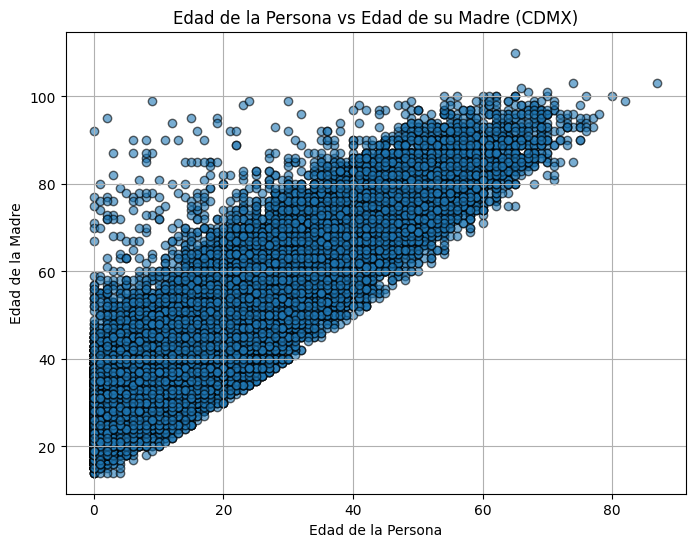

In [6]:
# Autojoin: Persona con su madre
df_join = df.merge(
    df,
    left_on=["ID_VIV", "IDMADRE"],
    right_on=["ID_VIV", "NUMPER"],
    how="inner",
    suffixes=("_PER", "_MADRE")
)

# Filtrar registros válidos (Excluimos valores faltantes, 88 y edades irreales)
df_valid = df_join[
    df_join["EDAD_PER"].notna() &
    df_join["EDAD_MADRE"].notna() &
    (df_join["EDAD_PER"] != 88) &
    (df_join["EDAD_MADRE"] != 88) &
    (df_join["EDAD_PER"].between(0, 111)) &
    (df_join["EDAD_MADRE"].between(0, 111))
]

# Grafica
plt.figure(figsize=(8, 6))
plt.scatter(df_valid["EDAD_PER"], df_valid["EDAD_MADRE"], alpha=0.6, edgecolor='k')
plt.title("Edad de la Persona vs Edad de su Madre (CDMX)")
plt.xlabel("Edad de la Persona")
plt.ylabel("Edad de la Madre")
plt.grid(True)
plt.show()

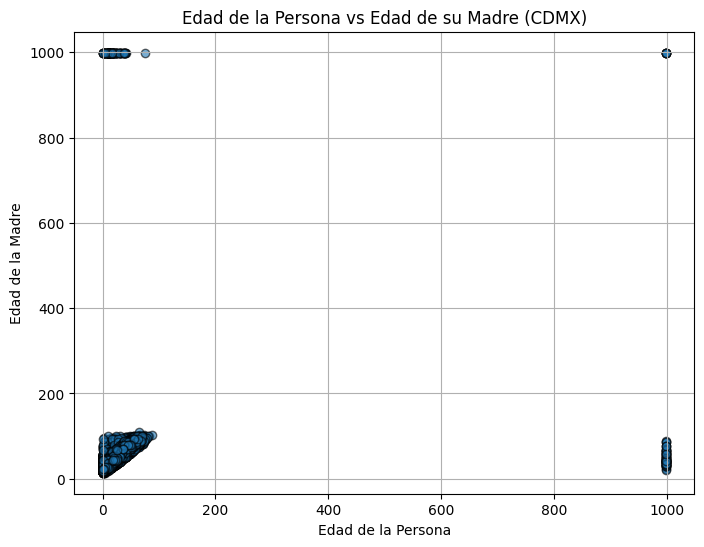

In [7]:
# Algo que podría pasar si no hacemos un buen filtro
df_valid = df_join.dropna(subset=["EDAD_PER", "EDAD_MADRE"])

# Grafica
plt.figure(figsize=(8, 6))
plt.scatter(df_valid["EDAD_PER"], df_valid["EDAD_MADRE"], alpha=0.6, edgecolor='k')
plt.title("Edad de la Persona vs Edad de su Madre (CDMX)")
plt.xlabel("Edad de la Persona")
plt.ylabel("Edad de la Madre")
plt.grid(True)
plt.show()